In [1]:
import xarray as xr
import fsspec
#import intake
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import ttest_ind, mstats

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

import dask
import pickle

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Set up figure

fs = fsspec.filesystem("")

In [2]:
path = '../create_analysis_dataset/data/'
path = 'data/'
var = 'UTCI'  # Can be changed to 'UTCI' or other heat indices
baseline_time = slice('1970', '1999')
recent_time = slice('1993', '2022')

In [3]:
da = xr.open_zarr(f'{path}/heat_analysis_set.zarr')[var] - 273.15
da = da.sel(latitude = slice(20,-60))

baseline = da.sel(time = baseline_time).chunk({"time": -1})
recent = da.sel(time = recent_time).chunk({"time": -1})

In [4]:
# Import GPD from scipy
from scipy.stats import genpareto as gpd


In [5]:
def fit_gpd(x, threshold_percentile=99):
    """
    Fit GPD to exceedances above threshold (99th percentile)
    """
    x = x[~np.isnan(x)]
    if len(x) < 10:
        return np.array([np.nan, np.nan, np.nan])
    
    try:
        # Calculate threshold (99th percentile)
        threshold = np.percentile(x, threshold_percentile)
        
        # Extract exceedances above threshold
        exceedances = x[x > threshold] - threshold
        
        if len(exceedances) < 5:  # Need minimum exceedances to fit
            return np.array([np.nan, np.nan, np.nan])
        
        # Fit GPD to exceedances with floc=0
        shape, loc, scale = gpd.fit(exceedances, floc=0)
        
        return np.array([shape, scale, threshold])
    except Exception:
        return np.array([np.nan, np.nan, np.nan])


In [6]:
def return_gpd(da):
    """
    Apply GPD fitting to data array
    """
    params = xr.apply_ufunc(
        fit_gpd,
        da,
        input_core_dims=[["time"]],
        output_core_dims=[["gpd_param"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"gpd_param": 3}},
    )
    params.name = "gpd_params"
    params.coords["gpd_param"] = ["gpd_shape", "gpd_scale", "gpd_threshold"]
    
    # Extract individual parameters
    shape = params.isel(gpd_param=0).drop_vars("gpd_param").rename("gpd_shape")
    scale = params.isel(gpd_param=1).drop_vars("gpd_param").rename("gpd_scale")
    threshold = params.isel(gpd_param=2).drop_vars("gpd_param").rename("gpd_threshold")
    
    return xr.Dataset(dict(gpd_shape=shape, gpd_scale=scale, gpd_threshold=threshold)).compute()


# Fit GPD to baseline and recent periods
baseline_gpd = return_gpd(baseline)
recent_gpd = return_gpd(recent)


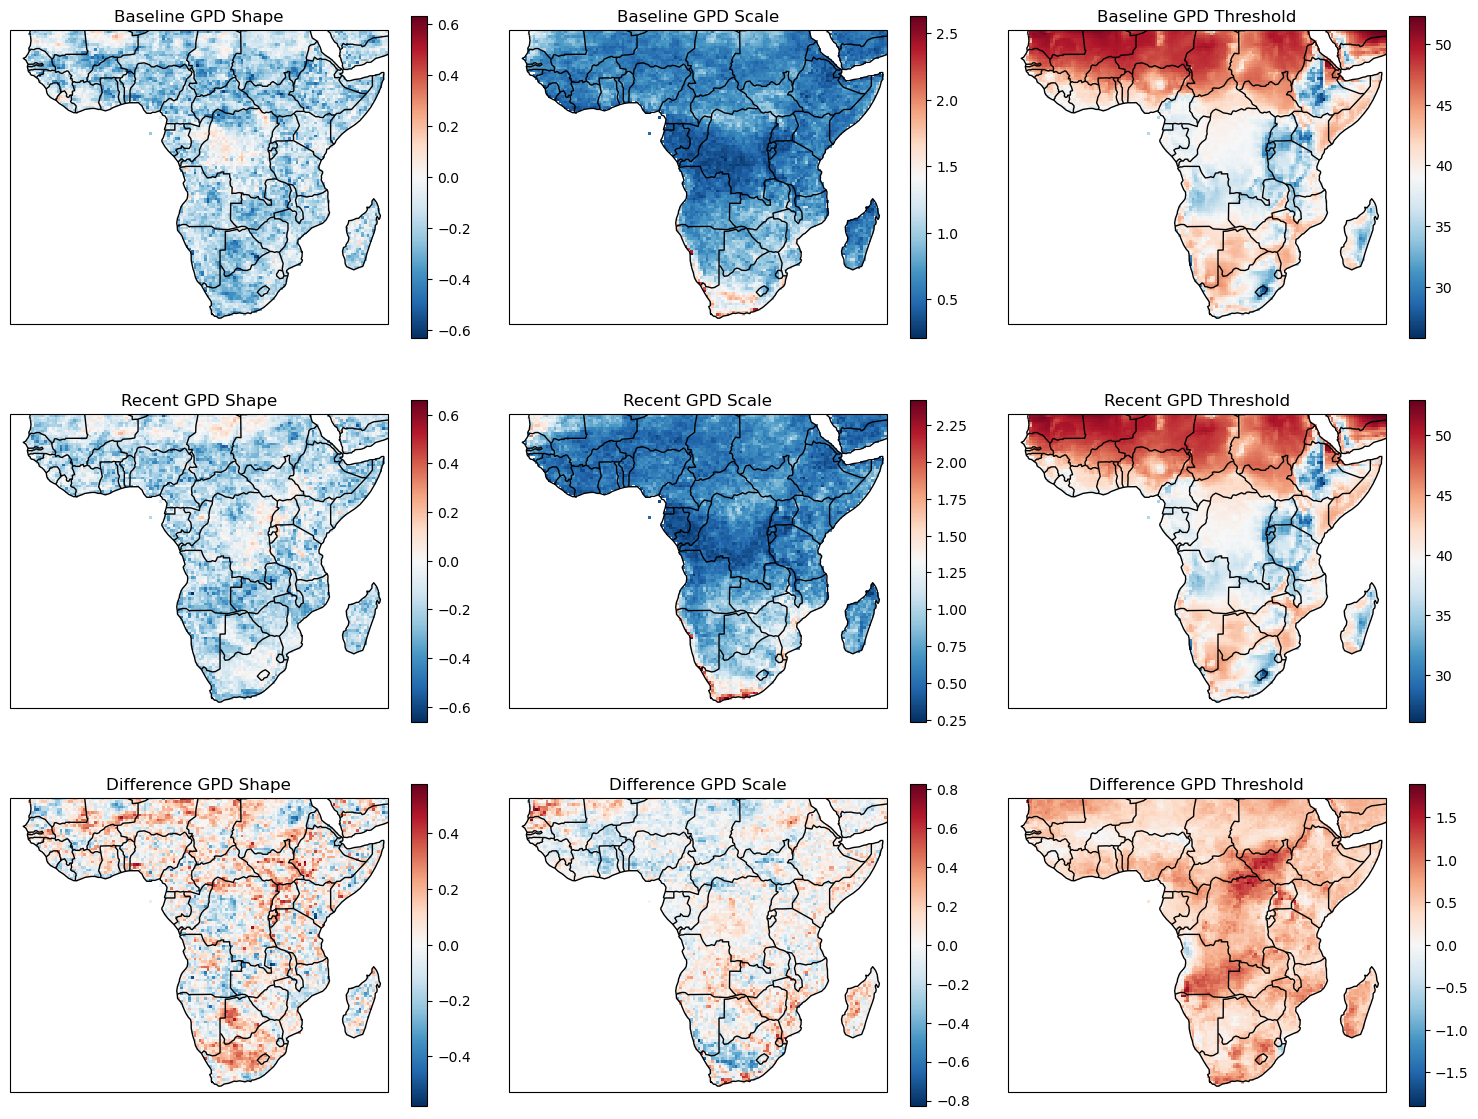

In [7]:
# Calculate differences between recent and baseline GPD
diff_gpd = recent_gpd - baseline_gpd

# Create a 3x3 plot of GPD parameters
fig, axes = plt.subplots(3, 3, figsize=(15, 12), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Define the parameters to plot
params = ['gpd_shape', 'gpd_scale', 'gpd_threshold']
param_names = ['Shape', 'Scale', 'Threshold']

# Top row: Baseline parameters
for col in range(3):
    ax = axes[0, col]
    param = params[col]
    param_name = param_names[col]
    
    im = baseline_gpd[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                                add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Baseline GPD {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Middle row: Recent parameters  
for col in range(3):
    ax = axes[1, col]
    param = params[col]
    param_name = param_names[col]
    
    im = recent_gpd[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                              add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Recent GPD {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Bottom row: Differences
for col in range(3):
    ax = axes[2, col]
    param = params[col]
    param_name = param_names[col]
    
    im = diff_gpd[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                            add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Difference GPD {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


In [8]:
da = da.chunk({'time': -1}).resample(time='1Y').max(dim='time')

baseline = da.sel(time = baseline_time).chunk({"time": -1})
recent = da.sel(time = recent_time).chunk({"time": -1})

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/xarray/groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


In [9]:
from scipy.stats import genextreme as gev
def fit_gev(x):
    x = x[~np.isnan(x)]
    if len(x) < 10:
        return np.array([np.nan, np.nan, np.nan])
    try:
        shape, loc, scale = gev.fit(x)
        return np.array([shape, loc, scale])
    except Exception:
        return np.array([np.nan, np.nan, np.nan])

In [10]:
def return_gev(da):
    """
    Fixed version of return_gev function that properly handles DataArray extraction
    """
    params = xr.apply_ufunc(
        fit_gev,
        da,
        input_core_dims=[["time"]],
        output_core_dims=[["gev_param"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"gev_param": 3}},
    )
    params.name = "gev_params"
    params.coords["gev_param"] = ["gev_shape", "gev_loc", "gev_scale"]
    
    # Extract individual parameters properly - this is the fix
    shape = params.isel(gev_param=0).drop_vars("gev_param").rename("gev_shape")
    loc = params.isel(gev_param=1).drop_vars("gev_param").rename("gev_loc")
    scale = params.isel(gev_param=2).drop_vars("gev_param").rename("gev_scale")
    
    return xr.Dataset(dict(gev_shape=shape, gev_loc=loc, gev_scale=scale)).compute()


baseline_gev = return_gev(baseline)
recent_gev = return_gev(recent)

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


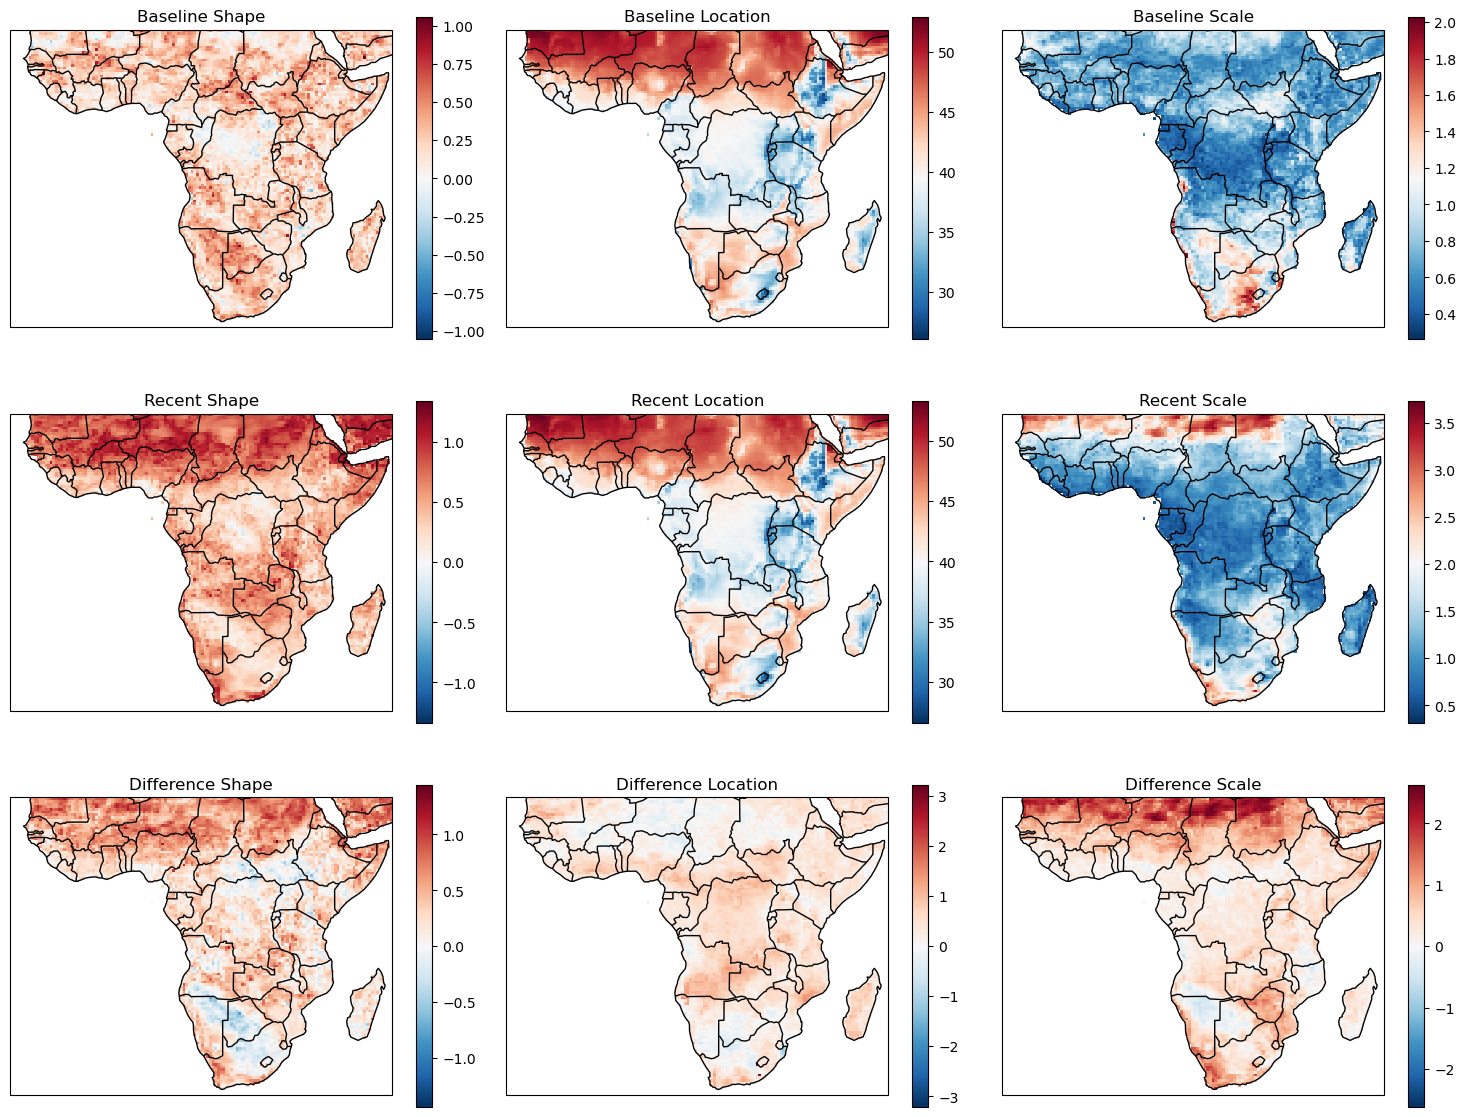

In [11]:
# Calculate differences between recent and baseline
diff_gev = recent_gev - baseline_gev

# Create a 3x3 plot of GEV parameters
fig, axes = plt.subplots(3, 3, figsize=(15, 12), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Define the parameters to plot
params = ['gev_shape', 'gev_loc', 'gev_scale']
param_names = ['Shape', 'Location', 'Scale']

# Top row: Baseline parameters
for col in range(3):
    ax = axes[0, col]
    param = params[col]
    param_name = param_names[col]
    
    im = baseline_gev[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                                add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Baseline {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Middle row: Recent parameters  
for col in range(3):
    ax = axes[1, col]
    param = params[col]
    param_name = param_names[col]
    
    im = recent_gev[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                              add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Recent {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Bottom row: Differences
for col in range(3):
    ax = axes[2, col]
    param = params[col]
    param_name = param_names[col]
    
    im = diff_gev[param].plot(ax=ax, transform=ccrs.PlateCarree(), 
                            add_colorbar=False, cmap='RdBu_r')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_title(f'Difference {param_name}', fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()
